# **Model Random Forest - Titanic**

## 1. Preparation

### 1.1 Import Library

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns
import tkinter as tk
from tkinter import messagebox

### 1.2 Import Dataset

In [50]:
df = pd.read_csv('titanic_train.csv')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [53]:
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

In [54]:
med_age = df['Age'].median()
df['Age'] =  df['Age'].fillna(med_age)
df['Cabin'] = df['Cabin'].fillna('NaN')

In [55]:
print(df['Sex'].unique())
print(df['Ticket'].unique())
print(df['Embarked'].unique())

['male' 'female']
['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450' '330877'
 '17463' '349909' '347742' '237736' 'PP 9549' '113783' 'A/5. 2151'
 '347082' '350406' '248706' '382652' '244373' '345763' '2649' '239865'
 '248698' '330923' '113788' '347077' '2631' '19950' '330959' '349216'
 'PC 17601' 'PC 17569' '335677' 'C.A. 24579' 'PC 17604' '113789' '2677'
 'A./5. 2152' '345764' '2651' '7546' '11668' '349253' 'SC/Paris 2123'
 '330958' 'S.C./A.4. 23567' '370371' '14311' '2662' '349237' '3101295'
 'A/4. 39886' 'PC 17572' '2926' '113509' '19947' 'C.A. 31026' '2697'
 'C.A. 34651' 'CA 2144' '2669' '113572' '36973' '347088' 'PC 17605' '2661'
 'C.A. 29395' 'S.P. 3464' '3101281' '315151' 'C.A. 33111' 'S.O.C. 14879'
 '2680' '1601' '348123' '349208' '374746' '248738' '364516' '345767'
 '345779' '330932' '113059' 'SO/C 14885' '3101278' 'W./C. 6608'
 'SOTON/OQ 392086' '343275' '343276' '347466' 'W.E.P. 5734' 'C.A. 2315'
 '364500' '374910' 'PC 17754' 'PC 17759' '231919' '244367' '349245'
 

In [56]:
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [57]:
print(df['Sex'].unique())
print(df['Embarked'].unique())

[0 1]
[0 1 2]


## 2. EDA

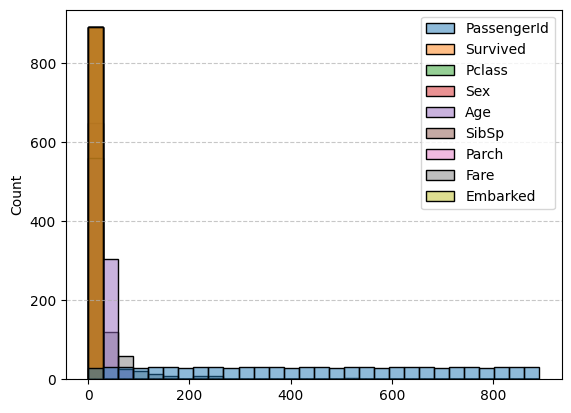

In [58]:
sns.histplot(data=df, bins=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

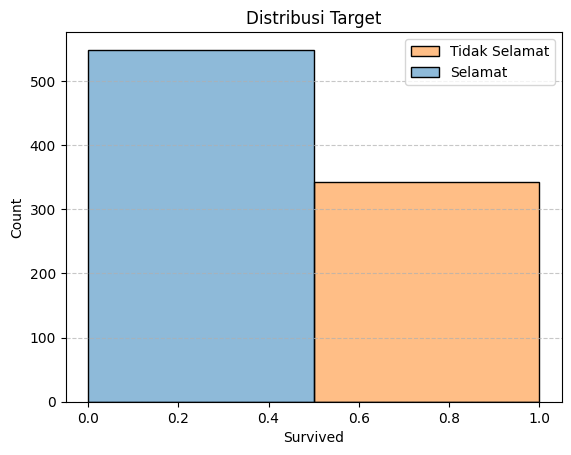

In [59]:
sns.histplot(data=df, x=df['Survived'], hue=df['Survived'], bins=2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(labels=['Tidak Selamat', 'Selamat'])
plt.title('Distribusi Target')
plt.show()

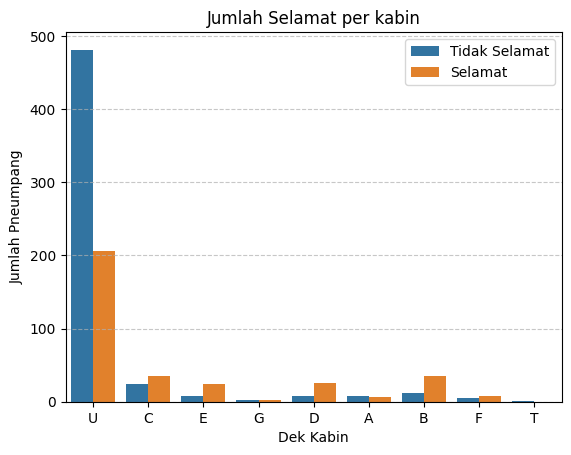

In [60]:
df['cab'] = df['Cabin'].apply(lambda x:  x[0] if pd.notna(x) else 'U')
df['cab'] = df['cab'].replace('N','U')

sns.countplot(data=df, x='cab', hue='Survived')
plt.xlabel('Dek Kabin')
plt.ylabel('Jumlah Pneumpang')
plt.title('Jumlah Selamat per kabin')
plt.legend(labels=['Tidak Selamat','Selamat'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Modeling

### 3.1 Independent & Dependent

In [61]:
X = df.drop(['Survived', 'Name', 'Ticket', 'Cabin'], axis=1).values
y = df['Survived'].values

### 3.2 Split Data

In [62]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(0.8 * len(idx_0))
train_1 = int(0.8 * len(idx_1))

train_idx = np.concatenate((idx_0[:train_0], idx_1[:train_1]))
test_idx = np.concatenate((idx_0[train_0:], idx_1[train_1:]))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

### 3.3 Decision Tree

In [63]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs ** 2)

class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5, max_features=None):
    if len(np.unique(y)) == 1 or depth >= max_depth or len(y) < 2:
        return DecisionTreeNode(value=np.argmax(np.bincount(y)))
    
    num_features = X.shape[1]
    if max_features is None:
        feature_to_sample = num_features
    elif max_features == 'sqrt':
        feature_to_sample = int(np.sqrt(num_features))
    else:
        feature_to_sample = int(max_features)

    feature_indices = np.random.choice(num_features, feature_to_sample, replace=False)

    best_gini = float('inf')
    best_feature = None
    best_threshold = None
    
    for feature in feature_indices:
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold
            if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                continue
            gini_left = gini_impurity(y[left_idx])
            gini_right = gini_impurity(y[right_idx])
            weighted_gini = (len(y[left_idx]) * gini_left + len(y[right_idx]) * gini_right) / len(y)
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature
                best_threshold = threshold
    
    if best_feature is None:
        return DecisionTreeNode(value=np.argmax(np.bincount(y)))
    
    left_idx = X[:, best_feature] <= best_threshold
    right_idx = X[:, best_feature] > best_threshold
    left = build_tree(X[left_idx], y[left_idx], depth + 1, max_depth)
    right = build_tree(X[right_idx], y[right_idx], depth + 1, max_depth)
    
    return DecisionTreeNode(feature=best_feature, threshold=best_threshold, left=left, right=right)


### 3.4 Random Forest

In [64]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=5, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
    def fit(self, X, y):
        self.trees = []
        nsamples = len(X_train)

        for _ in range(self.n_estimators):
            sample_indices = np.random.choice(nsamples, nsamples, replace=True)

            X_sample = X_train[sample_indices]
            Y_sample = y_train[sample_indices]

            tree = build_tree(X_sample, Y_sample, max_depth=self.max_depth, max_features=self.max_features)
            self.trees.append(tree)
    def predict_one(self, tree, X):
        node = tree
        while node.value is None:
            if X[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value
    

    def predict(self, X_test):
        predictions = np.array([self.predict_one(tree, x) for tree in self.trees for x in X_test])
        predictions = predictions.reshape(self.n_estimators, len(X_test))
        
        final_predictions = np.apply_along_axis(lambda x: np.argmax(np.bincount(x)), 0, predictions)
        
        return final_predictions

### 3.5 Inisiasi Random Forest

In [65]:
model_rf = RandomForest(n_estimators=100, max_depth=5, max_features='sqrt')
model_rf.fit(X_train, y_train)

### 3.6 Prediksi

In [66]:
y_pred = model_rf.predict(X_test)

### 3.7 Akurasi

In [67]:
def calculate_acc(y_true, y_pred):
     correct_predict = np.sum(y_true == y_pred)
     total_samples = len(y_true)
     return correct_predict / total_samples

accuracy = calculate_acc(y_test, y_pred)
print(accuracy)

0.8268156424581006


### 3.8 Best Depth

In [68]:
candidate = range(1,11)
best_accuracy = 0.0
best_depth = None
results = {}

for depth in candidate:
    search = RandomForest(n_estimators=100, max_depth=depth, max_features='sqrt')

    search.fit(X_train, y_train)

    y_pred_test = search.predict(X_test)

    current_acc = calculate_acc(y_test, y_pred_test)

    results[depth] = current_acc
    if current_acc > best_accuracy:
        best_accuracy = current_acc
        best_depth = depth

print(f"Max Depth Terbaik: {best_depth} dengan Akurasi: {best_accuracy:.4f}")

Max Depth Terbaik: 4 dengan Akurasi: 0.8324


In [71]:
est = range(2,51)
best_tree = None
best_accuracy_tree = 0.0
results_tree = {}

for n_trees in est:
    tree_search = RandomForest(n_estimators=n_trees, max_depth=best_depth, max_features='sqrt')

    tree_search.fit(X_train, y_train)
    y_pred_test_tree = tree_search.predict(X_test)
    current_acc_tree = calculate_acc(y_test, y_pred_test_tree)
    results_tree[n_trees] = current_acc_tree

    if current_acc_tree > best_accuracy_tree:
        best_accuracy_tree = current_acc_tree
        best_tree = n_trees

    print(f"akurasi w {n_trees} pohon {current_acc_tree:.4f}")

print(f"Jumlah pohon terbaik: {best_tree} akurasi: {best_accuracy_tree:.4f}")

akurasi w 2 pohon 0.7877
akurasi w 3 pohon 0.8045
akurasi w 4 pohon 0.8324
akurasi w 5 pohon 0.8101
akurasi w 6 pohon 0.8324
akurasi w 7 pohon 0.8212
akurasi w 8 pohon 0.8380
akurasi w 9 pohon 0.8212
akurasi w 10 pohon 0.8268
akurasi w 11 pohon 0.8268
akurasi w 12 pohon 0.8436
akurasi w 13 pohon 0.8324
akurasi w 14 pohon 0.8324
akurasi w 15 pohon 0.8380
akurasi w 16 pohon 0.8324
akurasi w 17 pohon 0.8324
akurasi w 18 pohon 0.8380
akurasi w 19 pohon 0.8212
akurasi w 20 pohon 0.8324
akurasi w 21 pohon 0.8268
akurasi w 22 pohon 0.8324
akurasi w 23 pohon 0.8156
akurasi w 24 pohon 0.8268
akurasi w 25 pohon 0.8436
akurasi w 26 pohon 0.8268
akurasi w 27 pohon 0.8324
akurasi w 28 pohon 0.8380
akurasi w 29 pohon 0.8324
akurasi w 30 pohon 0.8324
akurasi w 31 pohon 0.8268
akurasi w 32 pohon 0.8324
akurasi w 33 pohon 0.8324
akurasi w 34 pohon 0.8268
akurasi w 35 pohon 0.8324
akurasi w 36 pohon 0.8268
akurasi w 37 pohon 0.8268
akurasi w 38 pohon 0.8212
akurasi w 39 pohon 0.8492
akurasi w 40 pohon 0

### 3.9 Final Model

In [72]:
final_model = RandomForest(n_estimators=best_tree, max_depth=best_depth, max_features='sqrt')
final_model.fit(X_train, y_train)

### 3.10 Prediksi & Akurasi Final

In [73]:
y_pred_final = final_model.predict(X_test)
final_accuracy = calculate_acc(y_test, y_pred_final)

## 4. Evaluasi

In [74]:
def calculate_confusion_matrix(y_test, y_pred_final):
    TP = np.sum((y_test == 1) & (y_pred_final == 1))
    TN = np.sum((y_test == 0) & (y_pred_final == 0))
    FP = np.sum((y_test == 0) & (y_pred_final == 1))
    FN = np.sum((y_test == 1) & (y_pred_final == 0))
    
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    Recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1_Score = 2 * (Precision * Recall) / (Precision + Recall) if (Precision + Recall) > 0 else 0
    
    return {
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'Precision': Precision, 'Recall': Recall, 'F1_Score': F1_Score
    }

In [75]:
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

train_acc = calculate_acc(y_train, y_pred_train)
test_acc = calculate_acc(y_test, y_pred_test)

metrics = calculate_confusion_matrix(y_test, y_pred_final)
# metrics = calculate_confusion_matrix(y_test,y_pred)

print(f"True Positives (TP):    {metrics['TP']}")
print(f"True Negatives (TN):    {metrics['TN']}")
print(f"False Positives (FP):   {metrics['FP']}")
print(f"False Negatives (FN):   {metrics['FN']}\n")
print(f"Precision:              {metrics['Precision']:.4f}")
print(f"Recall:                 {metrics['Recall']:.4f}")
print(f"F1-Score:               {metrics['F1_Score']:.4f}\n")
print(f"Akurasi Train:          {train_acc * 100:.2f}%")
print(f"Akurasi Test:           {test_acc * 100:.2f}%")

True Positives (TP):    50
True Negatives (TN):    99
False Positives (FP):   11
False Negatives (FN):   19

Precision:              0.8197
Recall:                 0.7246
F1-Score:               0.7692

Akurasi Train:          85.39%
Akurasi Test:           83.24%


## 5. Visualisaasi

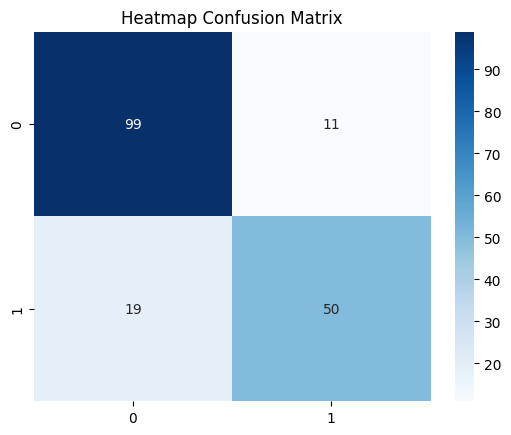

In [76]:
cm = np.array([
    [metrics['TN'], metrics['FP']],
    [metrics['FN'], metrics['TP']]
])

plt.Figure(figsize=(6,5))
sns.heatmap(cm, annot=True,cmap='Blues', fmt='d', xticklabels=['0', '1'], yticklabels=['0','1'])
plt.title('Heatmap Confusion Matrix')
plt.show()